In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

In [3]:
y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [4]:
print(X_test.shape)
print(y_test.shape)

(6000, 33)
(6000,)


In [5]:
model = joblib.load(
    "../models/random_forest_baseline.pkl"
)

In [6]:
y_pred = model.predict(X_test)

In [7]:
y_prob = model.predict_proba(X_test)

In [8]:
approve_probability = y_prob[:, 1]

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7963


In [10]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 0.7276


In [11]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 0.7429


In [12]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7352


In [13]:
roc_auc = roc_auc_score(
    y_test,
    approve_probability
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8655


In [14]:
print("Random Forest - Baseline Performance")
print("------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Random Forest - Baseline Performance
------------------------------------
Accuracy  : 0.7963
Precision : 0.7276
Recall    : 0.7429
F1 Score  : 0.7352
ROC-AUC   : 0.8655


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Reject", "Approve"]
    )
)

              precision    recall  f1-score   support

      Reject       0.84      0.83      0.83      3717
     Approve       0.73      0.74      0.74      2283

    accuracy                           0.80      6000
   macro avg       0.78      0.79      0.78      6000
weighted avg       0.80      0.80      0.80      6000



In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[3082  635]
 [ 587 1696]]


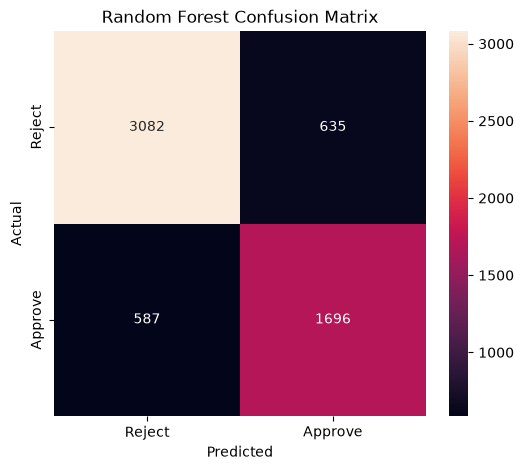

In [17]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Reject", "Approve"],
    yticklabels=["Reject", "Approve"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

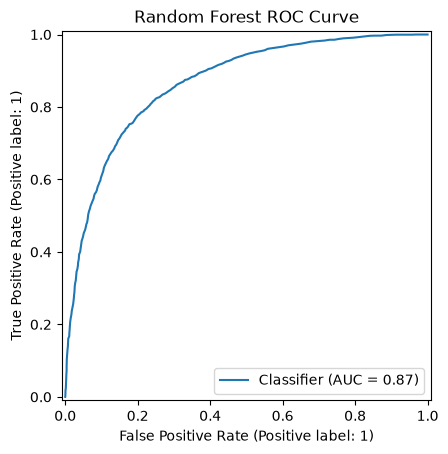

In [18]:
RocCurveDisplay.from_predictions(
    y_test,
    approve_probability
)

plt.title("Random Forest ROC Curve")

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": model.feature_importances_
})

In [20]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [21]:
feature_importance.head(15)

,Feature,Importance
9,Debt_to_Income_Ratio,0.151379
10,Loan_to_Income_Ratio,0.133394
19,Credit_Score,0.115655
4,Loan_Amount,0.069366
11,Credit_Utilization,0.052264
16,Credit_History_Length,0.049781
1,Annual_Income,0.046257
18,Payment_History,0.043904
2,Employment_Duration_Years,0.038480
0,Age,0.038478


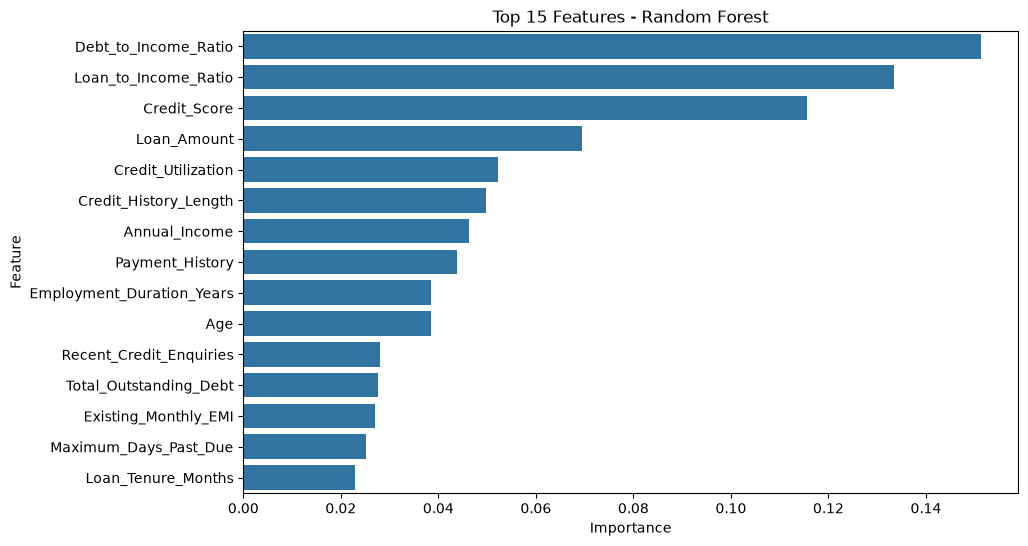

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.show()

In [23]:
tuned_model = joblib.load(
    "../models/random_forest_tuned.pkl"
)

In [24]:
y_pred_tuned = tuned_model.predict(X_test)

y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

In [25]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

In [26]:
print("Tuned Random Forest")
print("-------------------------")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")

Tuned Random Forest
-------------------------
Accuracy  : 0.7888
Precision : 0.7016
Recall    : 0.7744
F1 Score  : 0.7362
ROC-AUC   : 0.8687


In [27]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)

[[2965  752]
 [ 515 1768]]


In [28]:
model = joblib.load(
    "../models/random_forest_baseline.pkl"
)

In [29]:
approve_probability = model.predict_proba(X_test)[:, 1]

In [30]:
approve_probability = model.predict_proba(X_test)[:, 1]

In [31]:
import numpy as np

thresholds = np.arange(0.30, 0.81, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        approve_probability >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        ),
        "False_Approvals": fp,
        "False_Rejections": fn
    })

In [32]:
threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1,False_Approvals,False_Rejections
0,0.30,0.731333,0.598474,0.893123,0.716696,1368,244
1,0.35,0.755500,0.630602,0.862900,0.728685,1154,313
2,0.40,0.773167,0.661528,0.826982,0.735059,966,395
3,0.45,0.785500,0.690222,0.791502,0.737401,811,476
4,0.50,0.796000,0.725607,0.745948,0.735637,644,580
5,0.55,0.797167,0.752367,0.696014,0.723094,523,694
6,0.60,0.794833,0.782189,0.638633,0.703159,406,825
7,0.65,0.782500,0.800738,0.570302,0.666155,324,981
8,0.70,0.771833,0.829726,0.503723,0.626874,236,1133
9,0.75,0.755333,0.853426,0.431012,0.572759,169,1299


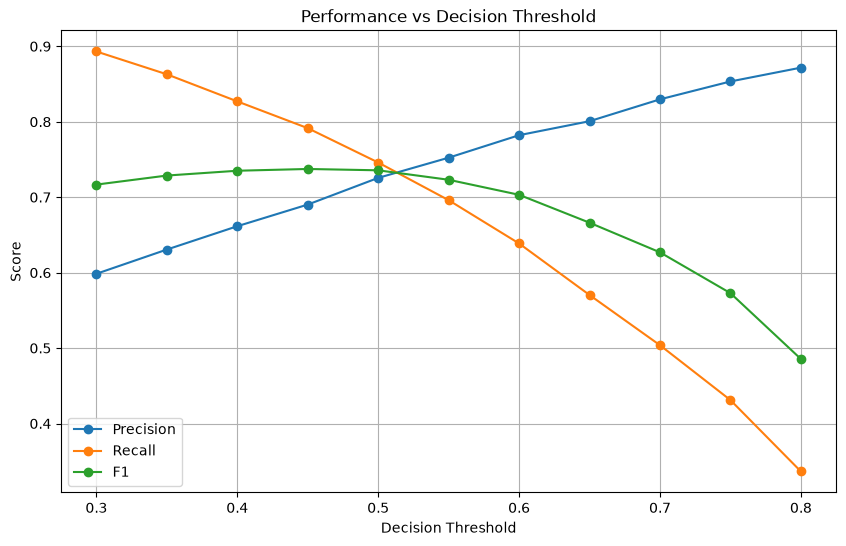

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Performance vs Decision Threshold")
plt.legend()
plt.grid()
plt.show()

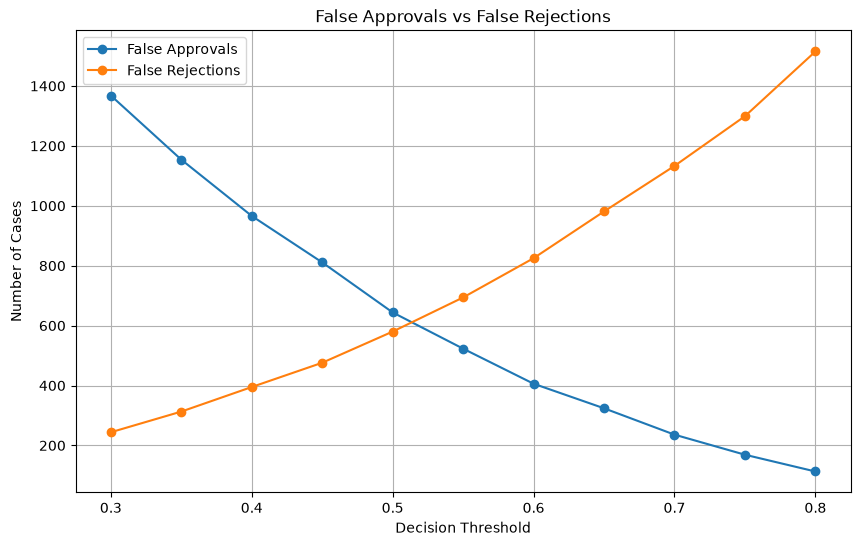

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False_Approvals"],
    marker="o",
    label="False Approvals"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False_Rejections"],
    marker="o",
    label="False Rejections"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Number of Cases")
plt.title("False Approvals vs False Rejections")
plt.legend()
plt.grid()
plt.show()

In [35]:
approve_probability = model.predict_proba(X_test)[0][1]

In [36]:
risk_score = (1 - approve_probability) * 100

In [37]:
if risk_score <= 30:
    risk_level = "LOW"
elif risk_score <= 60:
    risk_level = "MEDIUM"
else:
    risk_level = "HIGH"

In [38]:
if approve_probability >= 0.50:
    decision = "APPROVE"
else:
    decision = "REJECT"